# Wavefield · Elastic — source loadings + free-surface validation

The 2D ``Elastic`` equation in SWEEP exposes three stress
fields as source loadings (``sxx``, ``szz``, ``sxz``); the
particle-velocity fields are receiver-only. Different
combinations correspond to different seismic source mechanisms:

| Source type | Physical interpretation | What it excites |
|---|---|---|
| `['sxx', 'szz']` *(default)* | isotropic moment tensor (explosion) | pure P |
| `['szz']` | vertical normal stress (compressional dipole) | P + S |
| `['sxz']` | pure shear stress (double-couple) | pure S |

We use ``return_wavefield=True`` to grab snapshots at three
different times. Snapshot recording isn't compatible with chunk
checkpointing yet, so we explicitly use ``impl='eager',
use_ckpt=False``.


## 1. Parameters and uniform model

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Elastic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

shape = (200, 200)
dh    = 10.0
dt    = 0.0012
nt    = 400
freq, delay = 15.0, 0.07
vp_val, vs_val, rho_val = 2500.0, 1500.0, 2200.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, ' Vp/Vs ratio:', vp_val / vs_val)

vp_np  = np.full(shape, vp_val,  dtype=np.float32)
vs_np  = np.full(shape, vs_val,  dtype=np.float32)
rho_np = np.full(shape, rho_val, dtype=np.float32)
vp_t  = torch.tensor(vp_np,  device=device)
vs_t  = torch.tensor(vs_np,  device=device)
rho_t = torch.tensor(rho_np, device=device)
models = [vp_t, vs_t, rho_t]

# centred source — geometry-agnostic, makes the P/S rings easy to see
src_iz, src_ix = shape[0] // 2, shape[1] // 2
sources = np.array([[src_ix, src_iz]], dtype=np.int64)
# one dummy receiver; required by the API but we only look at wavefields
receivers = np.array([[[src_ix, src_iz + 4]]], dtype=np.int64)

t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq)
snapshot_times = [120, 200, 280]


device: cuda  Vp/Vs ratio: 1.6666666666666667


## 2. Build three solvers, one per source loading

``source_type=[...]`` is the only difference. The propagator additively
stamps the same Ricker pulse into every listed field at the source
location.


In [2]:
source_modes = [
    (['sxx', 'szz'], 'explosion (sxx+szz)'),
    (['szz'],        'compressional dipole (szz)'),
    (['sxz'],        'shear (sxz)'),
]

eq = Elastic(device=device)
snaps_per_mode = []
for src_type, label in source_modes:
    solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, nt=nt,
                       source_type=src_type,
                       impl='eager', use_ckpt=False)
    with torch.no_grad():
        rec, snaps = solver(wavelet, sources, receivers,
                            models=models,
                            return_wavefield=True,
                            snapshot_times=snapshot_times)
    snaps_per_mode.append((label, snaps.detach().cpu().numpy()))
    print(f'{label}: snaps {tuple(snaps.shape)}')


explosion (sxx+szz): snaps (3, 15, 1, 1, 300, 300)


compressional dipole (szz): snaps (3, 15, 1, 1, 300, 300)


shear (sxz): snaps (3, 15, 1, 1, 300, 300)


### Aside · which sources and receivers does this equation accept?

`Elastic` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [3]:
print('models (input order matters!):')
for spec in eq.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', eq.default_source_fields, '/', eq.default_receiver_fields)
print('receivers :')
for spec in eq.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — Elastic P-wave velocity model.
  - vs       [m/s]  — Elastic S-wave velocity model.
  - rho      [kg/m^3]  — Density model.
defaults  : ['sxx', 'szz'] / ['vx', 'vz']
receivers :
  - vx       aliases=('velocity_x',)  — Particle velocity in the x direction.
  - vz       aliases=('velocity_z',)  — Particle velocity in the z direction.
  - sxx      aliases=('stress_xx',)  — Normal stress in the x direction.
  - szz      aliases=('stress_zz',)  — Normal stress in the z direction.


## 3. Wavefield snapshots

For each source mode, three vertical-particle-velocity (`vz`) snapshots
at increasing times. The P-wave wavefront (`vp` = 2500 m/s) is the
**outer** ring and the S-wave wavefront (`vs` = 1500 m/s) is the
**inner** ring (slower).

Notice:

- **Explosion** (top row): only the outer P ring is visible; no S
  energy.
- **Compressional dipole `szz`** (middle row): both P and S rings,
  with characteristic vertical-lobe radiation pattern (P stronger on
  the vertical axis, S stronger on the diagonals).
- **Shear** (bottom row): only the inner S ring, with the classic
  four-lobe double-couple pattern.


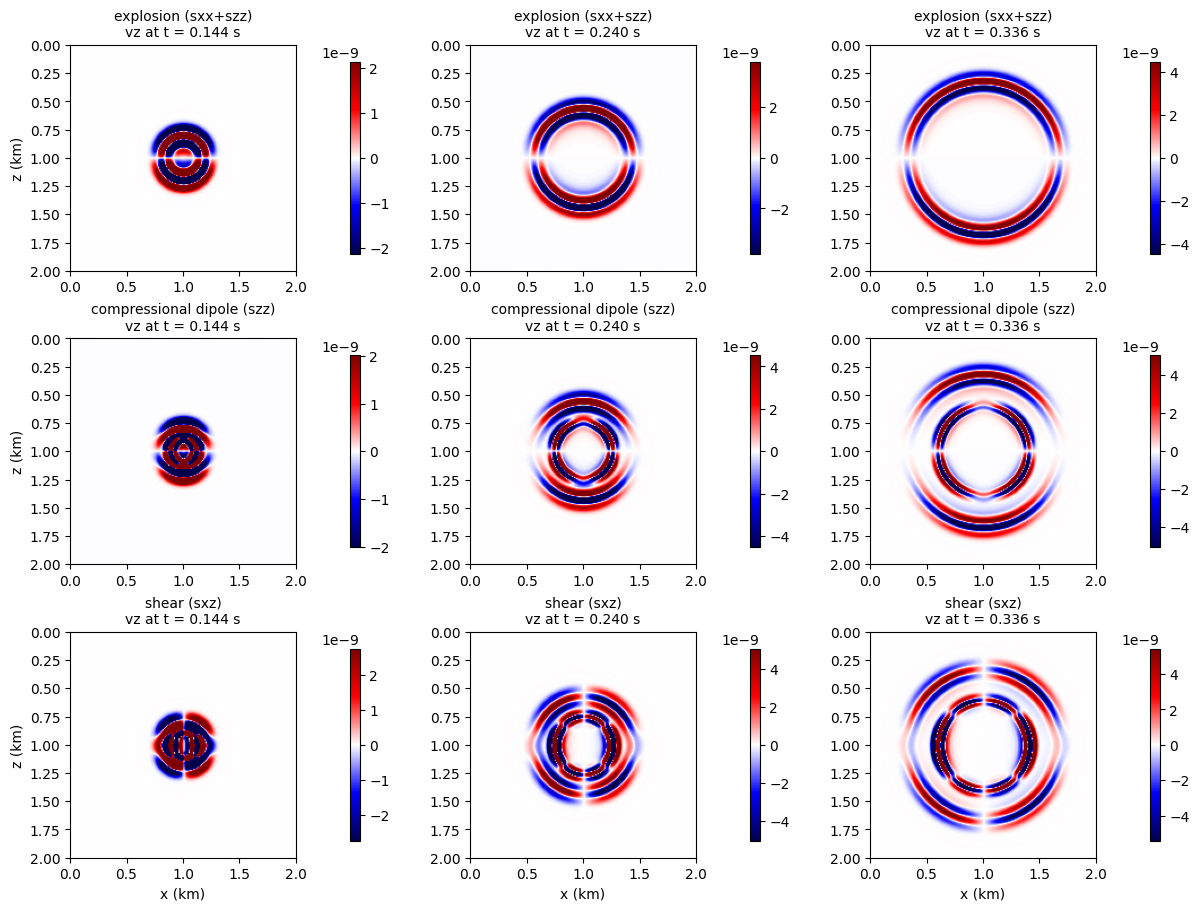

In [4]:
# Wavefield layout: (n_snapshots, n_fields, batch, ?, nz_pad, nx_pad)
# field 1 = vz; we crop PML padding for nicer display.
nz_pad, nx_pad = snaps_per_mode[0][1].shape[-2:]
pml = (nz_pad - shape[0]) // 2
vz_index = 1

fig, axes = plt.subplots(len(source_modes), len(snapshot_times),
                          figsize=(12, 9), constrained_layout=True)
for row, (label, arr) in enumerate(snaps_per_mode):
    for col, t_idx in enumerate(snapshot_times):
        field = arr[col, vz_index, 0, 0, pml:pml + shape[0], pml:pml + shape[1]]
        vmin, vmax = np.percentile(field, [2, 98])
        ax = axes[row, col]
        im = ax.imshow(field, cmap='seismic', vmin=vmin, vmax=vmax,
                       extent=[0, shape[1]*dh/1000, shape[0]*dh/1000, 0])
        ax.set_title(f'{label}\nvz at t = {t_idx * dt:.3f} s', fontsize=10)
        if col == 0: ax.set_ylabel('z (km)')
        if row == len(source_modes) - 1: ax.set_xlabel('x (km)')
        fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()


## 4. Free-surface BC validation against a vacuum layer

How do you know ``free_surface=True`` actually models a free
surface? A physical free surface can be approximated by a vacuum
top layer (``vp ≈ 0``, ``vs = 0``, same ``ρ``): the P-impedance
contrast between vacuum and elastic gives reflection coefficient
``R_PP ≈ -0.999 ≈ -1`` — exactly what a free surface should do.

If the implementation is right, the two setups produce essentially
identical shot gathers and wavefield snapshots.


In [5]:
from sweep.propagator.options import EagerOptions
fs_nz, fs_nx = 200, 200
fs_dh, fs_dt = 10.0, 1e-3
fs_nt = 2001
fs_freq, fs_delay = 6.0, 0.33   # 6 Hz (not 10): the Rayleigh wave runs at
# vR = 0.9194*vs = 919 m/s, so at dh=10 m a 10 Hz wavelet gives only ~9 points
# per Rayleigh wavelength -- enough for the body waves (vp=2000 -> ppw 20) but
# not for the surface wave, which then trails visible grid dispersion.  6 Hz
# lifts it to ppw ~15 at zero extra cost (ppw scales as 1/f0).
fs_abcn = 20
fs_order = 4
n_vac = 30
src_off = 10
SRC_X = fs_nx // 2
snap_times = [300, 600, 900]
rec_xs = np.arange(0, fs_nx, 2)
rec_snap = np.array([[[SRC_X, fs_nz // 2]]], dtype=np.int64)
fs_t = np.arange(fs_nt, dtype=np.float32) * fs_dt
fs_wav = ricker(fs_t - fs_delay, f=fs_freq)

vp1 = np.full((fs_nz, fs_nx), 2000.0, dtype=np.float32)
vs1 = np.full((fs_nz, fs_nx), 1000.0, dtype=np.float32)
rho1 = np.full((fs_nz, fs_nx), 2000.0, dtype=np.float32)
vp2 = np.full((fs_nz, fs_nx), 2000.0, dtype=np.float32)
vp2[:n_vac, :] = 1.0
vs2 = np.zeros((fs_nz, fs_nx), dtype=np.float32)
vs2[n_vac:, :] = 1000.0
rho2 = np.full((fs_nz, fs_nx), 2000.0, dtype=np.float32)

src1 = np.array([[SRC_X, src_off]], dtype=np.int64)
src2 = np.array([[SRC_X, n_vac + src_off]], dtype=np.int64)
rec1 = np.array([[[x, 0]     for x in rec_xs]], dtype=np.int64)
rec2 = np.array([[[x, n_vac] for x in rec_xs]], dtype=np.int64)

def build_fs(vp, vs, rho, free_surface):
    e = Elastic(spatial_order=fs_order, device=device)
    s = PropTorch(e, shape=(fs_nz, fs_nx), abcn=fs_abcn, dh=fs_dh, dt=fs_dt, nt=fs_nt,
                  source_type=['sxx','szz'], receiver_type=['vz'], free_surface=free_surface, impl='eager', use_ckpt=False,
                  eager_options=EagerOptions(use_compile=False))
    return e, s, [torch.tensor(vp, device=device),
                  torch.tensor(vs, device=device),
                  torch.tensor(rho, device=device)]

e1, s1, m1 = build_fs(vp1, vs1, rho1, free_surface=True)
e2, s2, m2 = build_fs(vp2, vs2, rho2, free_surface=False)

with torch.no_grad():
    rec_out1 = s1(fs_wav, src1, rec1, models=m1)
    rec_out2 = s2(fs_wav, src2, rec2, models=m2)
    _, snaps1 = s1(fs_wav, src1, rec_snap, models=m1,
                   return_wavefield=True, snapshot_times=snap_times)
    _, snaps2 = s2(fs_wav, src2, rec_snap, models=m2,
                   return_wavefield=True, snapshot_times=snap_times)
print('records:', tuple(rec_out1.shape), tuple(rec_out2.shape))
print('snaps:  ', tuple(snaps1.shape),    tuple(snaps2.shape))


records: (1, 2001, 100, 1) (1, 2001, 100, 1)
snaps:   (3, 15, 1, 1, 220, 240) (3, 15, 1, 1, 240, 240)


### 4a. Gather comparison


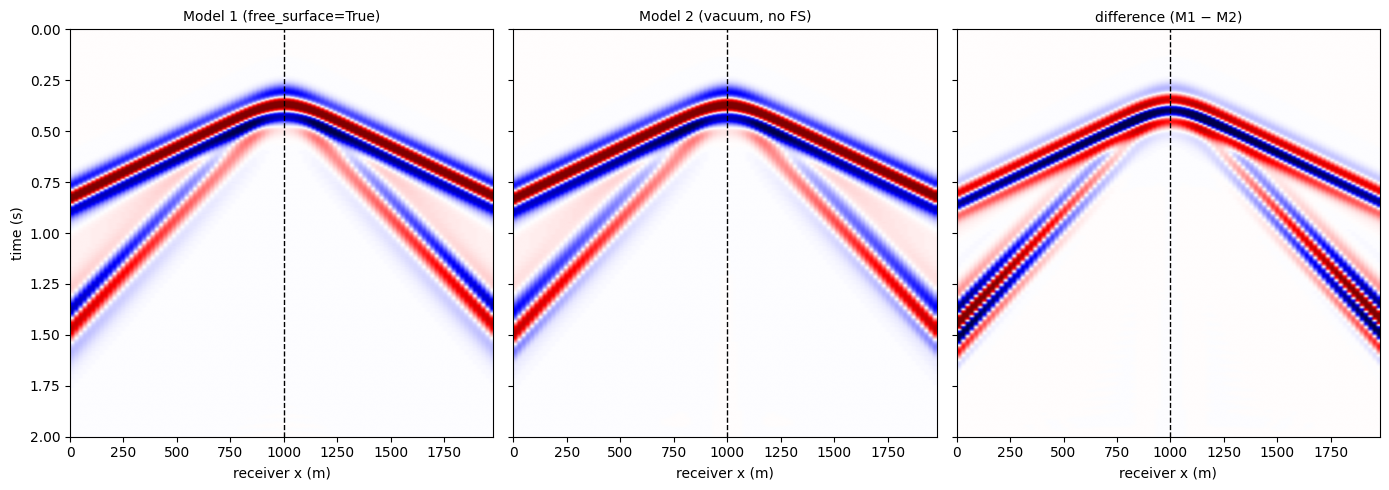

In [6]:
vz1 = rec_out1[0, :, :, 0].cpu().numpy()
vz2 = rec_out2[0, :, :, 0].cpu().numpy()
def norm_traces(a):
    mx = np.abs(a).max(axis=0, keepdims=True)
    return a / np.where(mx < 1e-30, 1.0, mx)
vz1n, vz2n = norm_traces(vz1), norm_traces(vz2)
diff = vz1n - vz2n
extent_g = [rec_xs[0]*fs_dh, rec_xs[-1]*fs_dh, fs_t[-1], fs_t[0]]
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, panel, title, vlim in zip(
    axes,
    [vz1n, vz2n, diff],
    ['Model 1 (free_surface=True)', 'Model 2 (vacuum, no FS)', 'difference (M1 − M2)'],
    [0.8, 0.8, 0.2]):
    ax.imshow(panel, aspect='auto', cmap='seismic',
              vmin=-vlim, vmax=vlim, extent=extent_g)
    ax.axvline(SRC_X * fs_dh, color='k', lw=1.0, ls='--')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('receiver x (m)')
axes[0].set_ylabel('time (s)')
plt.tight_layout()
plt.show()


### 4b. Wavefield snapshot comparison


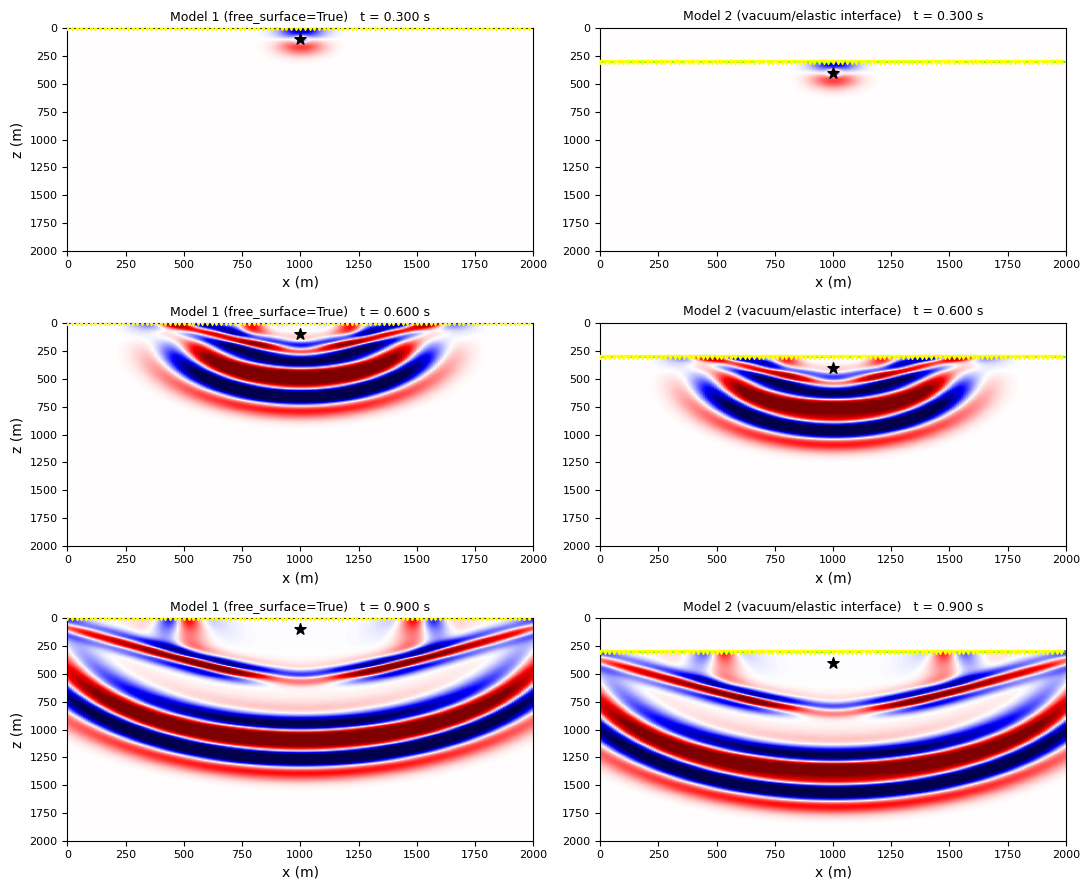

In [7]:
VZ_IDX = 1
def crop(snap_2d, free_surface):
    if free_surface:
        return snap_2d[:fs_nz, fs_abcn:fs_abcn + fs_nx]
    return snap_2d[fs_abcn:fs_abcn + fs_nz, fs_abcn:fs_abcn + fs_nx]
rec_x_m = rec_xs * fs_dh
fig, axes = plt.subplots(len(snap_times), 2,
                          figsize=(11, 3.0 * len(snap_times)))
for row, t_idx in enumerate(snap_times):
    s1f = crop(snaps1[row, VZ_IDX, 0, 0].cpu().numpy(), free_surface=True)
    s2f = crop(snaps2[row, VZ_IDX, 0, 0].cpu().numpy(), free_surface=False)
    vmax = max(np.abs(s1f).max(), np.abs(s2f).max()) * 0.6
    if vmax < 1e-30: vmax = 1.0
    extent = [0, fs_nx * fs_dh, fs_nz * fs_dh, 0]
    kw = dict(aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax, extent=extent)
    for ax, panel, fs_flag, surface_z, label in zip(
        axes[row],
        [s1f, s2f],
        [True, False],
        [0.0, n_vac * fs_dh],
        ['Model 1 (free_surface=True)', 'Model 2 (vacuum/elastic interface)']):
        ax.imshow(panel, **kw)
        ax.axhline(surface_z, color='lime', lw=1.2, ls='--')
        ax.scatter([SRC_X * fs_dh],
                   [(src_off if fs_flag else n_vac + src_off) * fs_dh],
                   c='k', s=70, marker='*', zorder=6)
        ax.scatter(rec_x_m, np.full_like(rec_x_m, surface_z, dtype=float),
                   c='yellow', s=8, marker='v', zorder=5)
        ax.set_title(f'{label}   t = {t_idx * fs_dt:.3f} s', fontsize=9)
        ax.set_xlabel('x (m)')
        ax.tick_params(labelsize=8)
    axes[row, 0].set_ylabel('z (m)')
plt.tight_layout()
plt.show()


## References

1. Virieux, J. (1986). P-SV wave propagation in heterogeneous media: Velocity-stress finite-difference method. *Geophysics, 51*(4), 889–901. [doi:10.1190/1.1442147](https://doi.org/10.1190/1.1442147) — the staggered-grid elastic wave equation used here.
2. Robertsson, J. O. A. (1996). A numerical free-surface condition for elastic/viscoelastic finite-difference modeling in the presence of topography. *Geophysics, 61*(6), 1921–1934. [doi:10.1190/1.1444107](https://doi.org/10.1190/1.1444107) — the odd-parity stress-mirror free-surface boundary condition (`free_surface=True` / `topo_method='image'` for `Elastic`) validated in section 4.

---

<p><strong>Download this notebook</strong> &mdash; <a href="06_wavefield_elastic.ipynb" download><code>06_wavefield_elastic.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/06_wavefield_elastic.ipynb">view on GitHub</a></p>
